# Building structured multi-plot grids

📄 Source: https://seaborn.pydata.org/tutorial/axis_grids.html

**Small multiples** ("lattice" / "trellis" plots): the same plot drawn on different subsets of the data, so the eye can compare them quickly. Seaborn links the structure of the plot to the structure of the dataset.

The figure-level functions (`relplot`, `displot`, `catplot`, `lmplot`) are built on the objects in this notebook and handle the bookkeeping for you, so use them in most cases. This page explains the underlying objects for advanced use.

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="ticks")
np.random.seed(sum(map(ord, "axis_grids")))
print("seaborn", sns.__version__)

seaborn 0.13.2


## Conditional small multiples

`FacetGrid` shows a distribution or relationship **separately within subsets**. Up to three dimensions: `row`, `col` (the grid of Axes) and `hue` (a "depth" dimension shown with colour). Those variables should be categorical/discrete.

`relplot`, `displot`, `catplot` and `lmplot` use it internally and **return** it so you can tweak the result.

Create it with a DataFrame and the faceting variables. This sets up the figure and Axes but **draws nothing**:

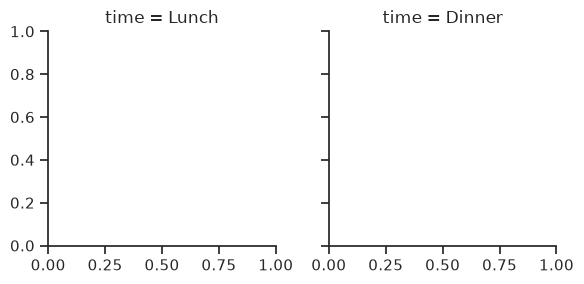

In [2]:
tips = sns.load_dataset("tips")
g = sns.FacetGrid(tips, col="time")   # 2 empty panels: Lunch, Dinner

Draw with **`FacetGrid.map(plot_function, "column", ...)`**:

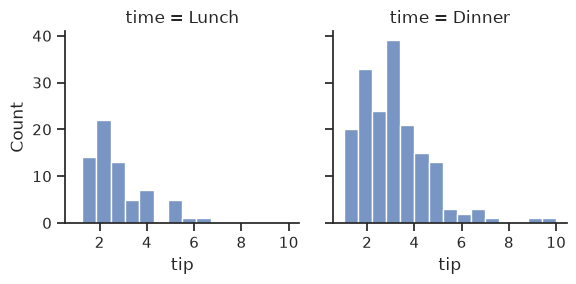

In [3]:
g = sns.FacetGrid(tips, col="time")
g.map(sns.histplot, "tip")   # histplot(x=tips subset "tip") in each panel

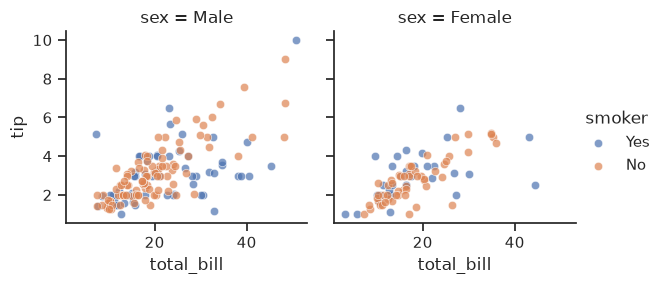

In [4]:
# Relational plot: pass two column names; extra keyword args go to the plot function
g = sns.FacetGrid(tips, col="sex", hue="smoker")
g.map(sns.scatterplot, "total_bill", "tip", alpha=.7)
g.add_legend()

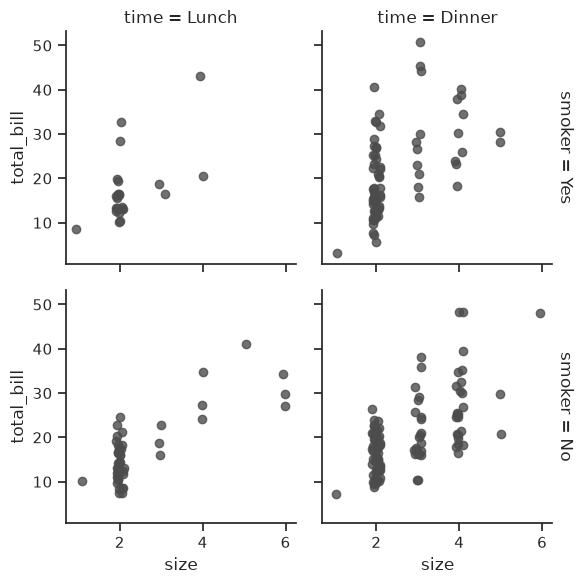

In [5]:
# margin_titles=True: row titles on the right margin instead of above each panel
g = sns.FacetGrid(tips, row="smoker", col="time", margin_titles=True)
g.map(sns.regplot, "size", "total_bill", color=".3", fit_reg=False, x_jitter=.1)

(`margin_titles` isn't official matplotlib API and doesn't work with a legend outside the plot.)

**Size** = `height` of **each** facet + `aspect` ratio:

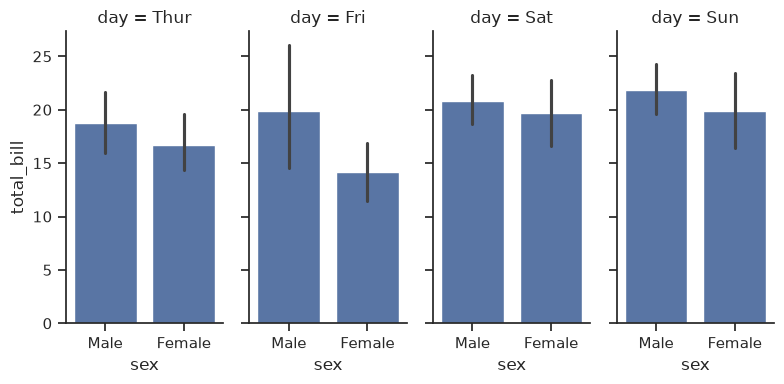

In [6]:
g = sns.FacetGrid(tips, col="day", height=4, aspect=.5)
g.map(sns.barplot, "sex", "total_bill", order=["Male", "Female"])   # give order= so every panel matches

**Facet order** comes from a categorical dtype or order of appearance; override with `row_order` / `col_order` / `hue_order`:

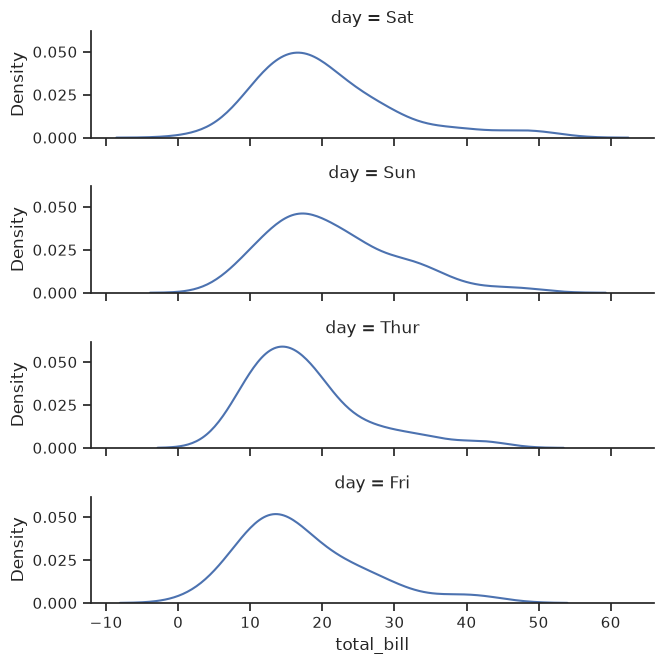

In [7]:
ordered_days = tips.day.value_counts().index   # most common day first
g = sns.FacetGrid(tips, row="day", row_order=ordered_days,
                  height=1.7, aspect=4,)
g.map(sns.kdeplot, "total_bill")

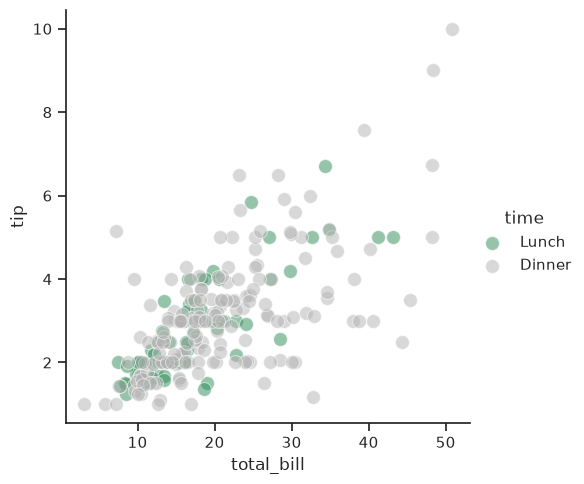

In [8]:
# Any palette, or a dict mapping hue values -> colours
pal = dict(Lunch="seagreen", Dinner=".7")
g = sns.FacetGrid(tips, hue="time", palette=pal, height=5)
g.map(sns.scatterplot, "total_bill", "tip", s=100, alpha=.5)
g.add_legend()

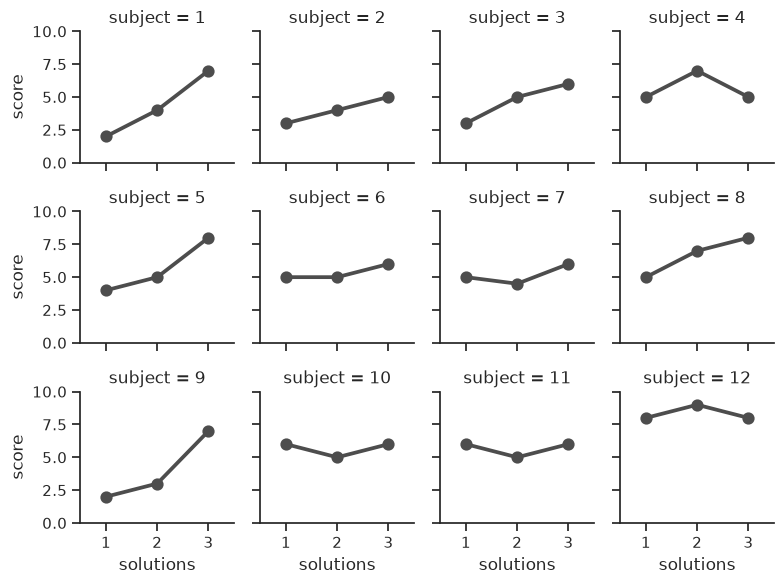

In [9]:
# Many levels: wrap the columns into rows with col_wrap (then you can't use row=)
attend = sns.load_dataset("attention").query("subject <= 12")
g = sns.FacetGrid(attend, col="subject", col_wrap=4, height=2, ylim=(0, 10))
g.map(sns.pointplot, "solutions", "score", order=[1, 2, 3], color=".3", errorbar=None)

After `map` (which can be called several times), adjust the figure with grid-level methods. `g.set(...)` is the most general; `g.set_axis_labels` knows inner facets have no labels:

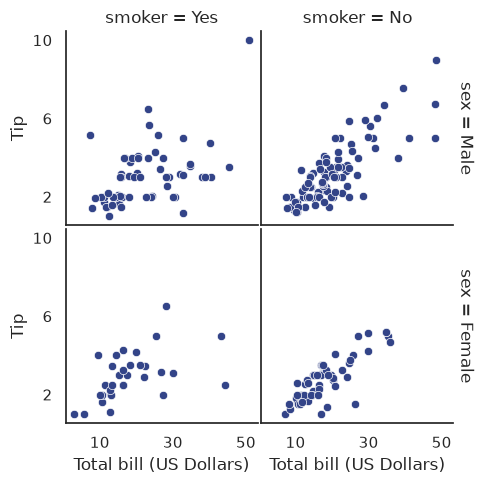

In [10]:
with sns.axes_style("white"):   # temporary style, only for this grid
    g = sns.FacetGrid(tips, row="sex", col="smoker", margin_titles=True, height=2.5)
g.map(sns.scatterplot, "total_bill", "tip", color="#334488")
g.set_axis_labels("Total bill (US Dollars)", "Tip")
g.set(xticks=[10, 30, 50], yticks=[2, 6, 10])      # applied to every Axes
g.figure.subplots_adjust(wspace=.02, hspace=.02)   # matplotlib Figure method

For full control, use the matplotlib objects directly: `g.figure`, `g.axes` (array), `g.axes_dict` (dict keyed by facet value), and `g.ax` when there's only one Axes:

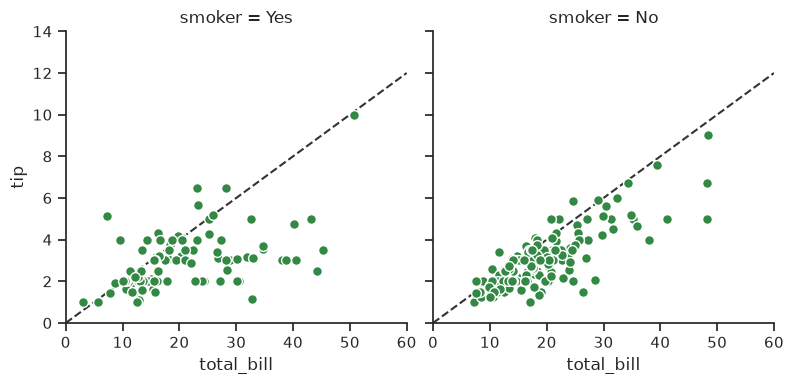

In [11]:
g = sns.FacetGrid(tips, col="smoker", margin_titles=True, height=4)
g.map(plt.scatter, "total_bill", "tip", color="#338844", edgecolor="white", s=50, lw=1)   # a plain matplotlib function works too
for ax in g.axes_dict.values():
    ax.axline((0, 0), slope=.2, c=".2", ls="--", zorder=0)   # a "20% tip" reference line in each panel
g.set(xlim=(0, 60), ylim=(0, 14))

**`map` vs `map_dataframe`** (my addition, mentioned in the README): `map` passes **Series** positionally; `map_dataframe` passes the subset **DataFrame** as `data=` plus your column names as keywords, which suits seaborn functions:

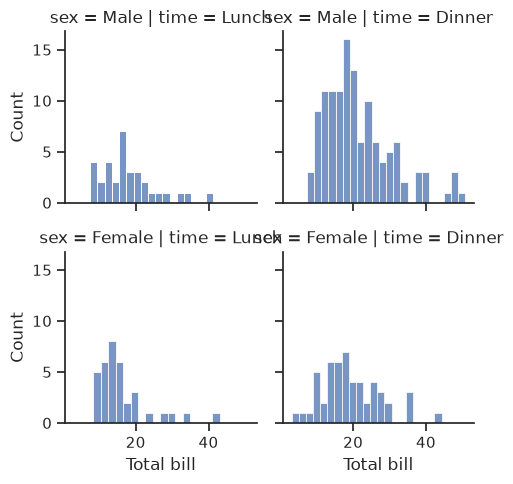

In [12]:
g = sns.FacetGrid(tips, col="time", row="sex", height=2.5)
g.map_dataframe(sns.histplot, x="total_bill", binwidth=2)   # called as histplot(data=subset, x="total_bill", ...)
g.set_axis_labels("Total bill", "Count")

## Using custom functions

Any function works with `FacetGrid` if it:
1. plots onto the **currently active** matplotlib Axes (`plt.*` functions do; or call `plt.gca()`),
2. accepts the data as **positional arguments** (FacetGrid passes one Series per column name),
3. accepts **`color`** and **`label`** keyword arguments (easiest: catch `**kwargs` and pass them on).

Minimal example: one vector per facet (a quantile plot):

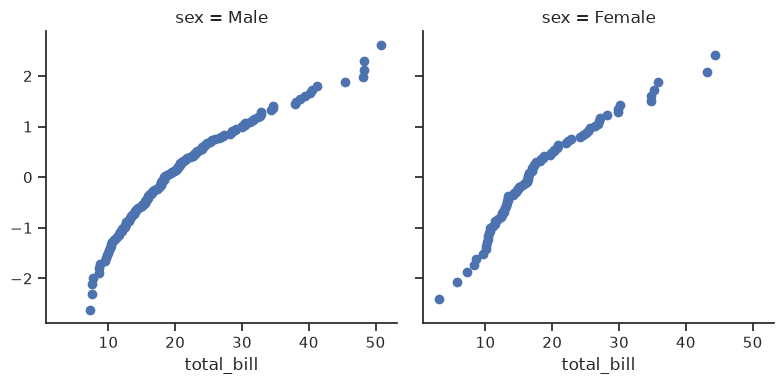

In [13]:
from scipy import stats

def quantile_plot(x, **kwargs):
    quantiles, xr = stats.probplot(x, fit=False)   # theoretical vs observed quantiles
    plt.scatter(xr, quantiles, **kwargs)           # draws on the current Axes; passes color/label on

g = sns.FacetGrid(tips, col="sex", height=4)
g.map(quantile_plot, "total_bill")

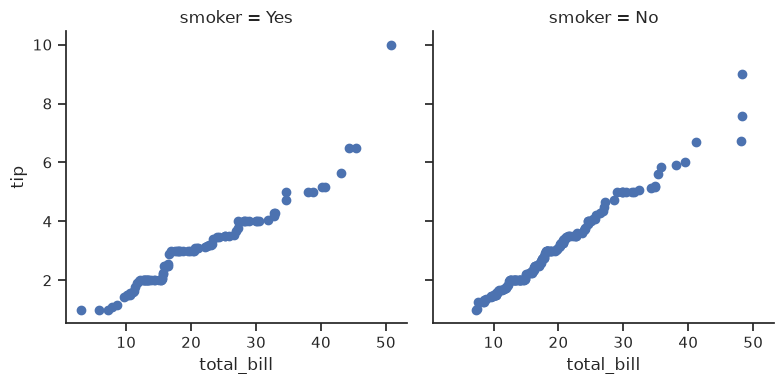

In [14]:
# Bivariate: accept x first, then y
def qqplot(x, y, **kwargs):
    _, xr = stats.probplot(x, fit=False)
    _, yr = stats.probplot(y, fit=False)
    plt.scatter(xr, yr, **kwargs)

g = sns.FacetGrid(tips, col="smoker", height=4)
g.map(qqplot, "total_bill", "tip")

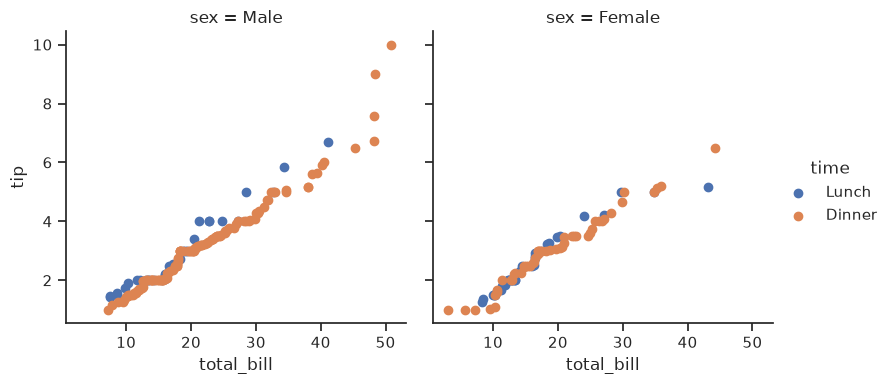

In [15]:
# plt.scatter handles color/label correctly, so hue just works
g = sns.FacetGrid(tips, hue="time", col="sex", height=4)
g.map(qqplot, "total_bill", "tip")
g.add_legend()

If a function doesn't handle `color`/`label` the way you want, catch them explicitly. This makes `plt.hexbin` work with FacetGrid:

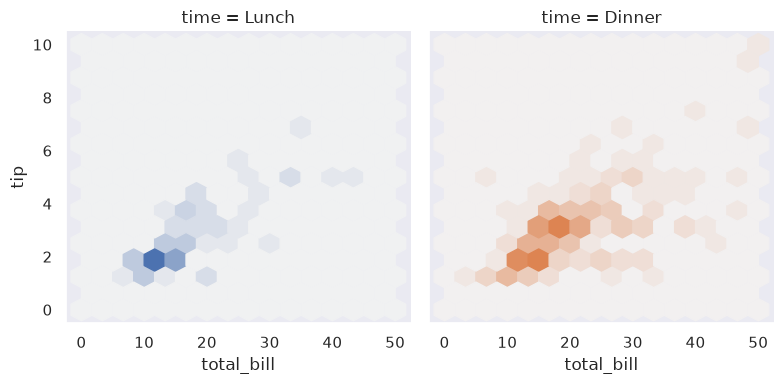

In [16]:
def hexbin(x, y, color, **kwargs):
    cmap = sns.light_palette(color, as_cmap=True)   # turn the facet's colour into a colormap
    plt.hexbin(x, y, gridsize=15, cmap=cmap, **kwargs)

with sns.axes_style("dark"):
    g = sns.FacetGrid(tips, hue="time", col="time", height=4)
g.map(hexbin, "total_bill", "tip", extent=[0, 50, 0, 10]);

## Plotting pairwise data relationships

`PairGrid`: each row and column is a **different variable**, so every panel shows a **different pairwise relationship** (a "scatterplot matrix", but not limited to scatterplots).

> **FacetGrid** = the **same** relationship, conditioned on levels of other variables.
> **PairGrid** = a **different** relationship in each panel.

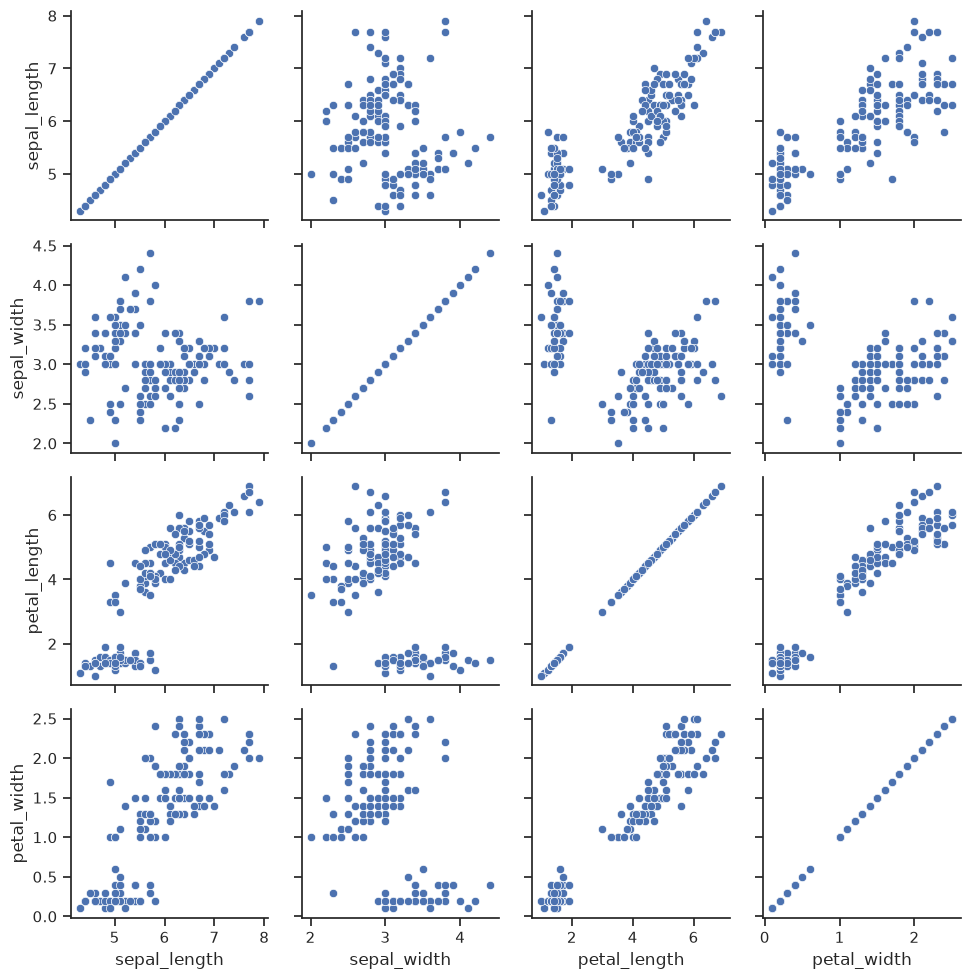

In [17]:
iris = sns.load_dataset("iris")
g = sns.PairGrid(iris)
g.map(sns.scatterplot)   # same function in every panel

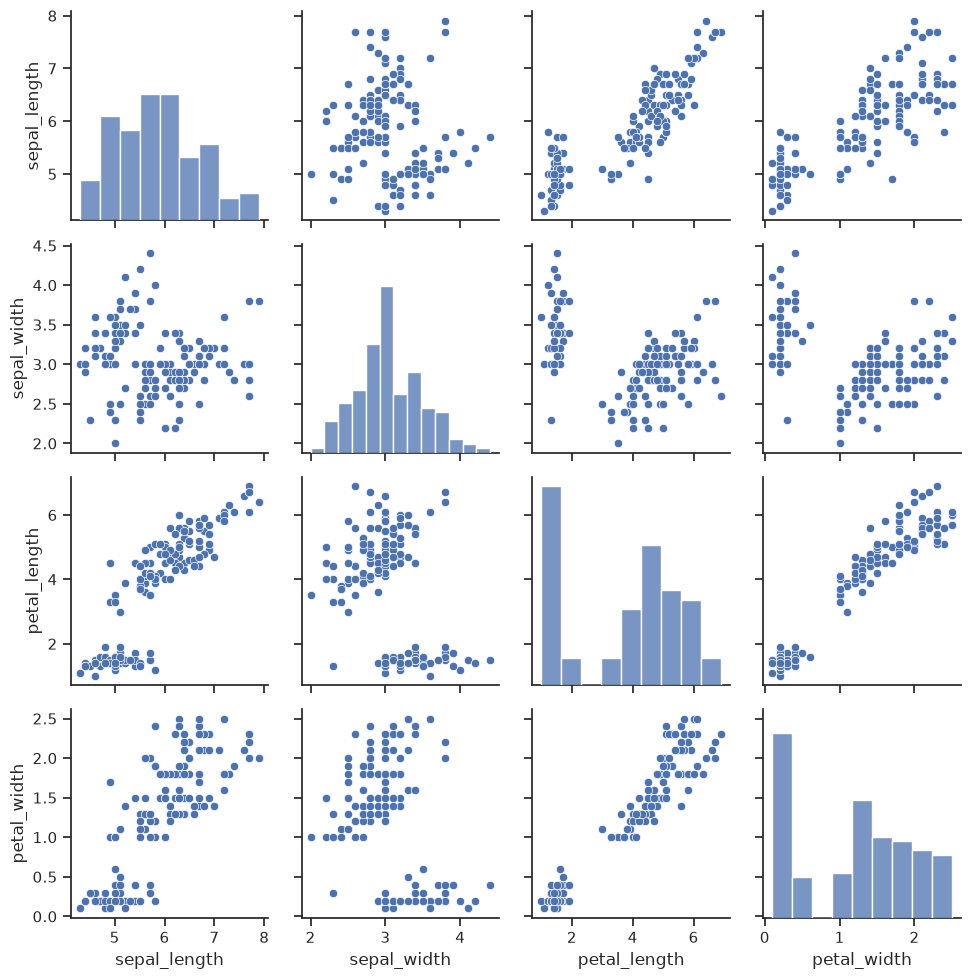

In [18]:
# A different function on the diagonal (univariate distribution; its ticks don't show the counts)
g = sns.PairGrid(iris)
g.map_diag(sns.histplot)
g.map_offdiag(sns.scatterplot)

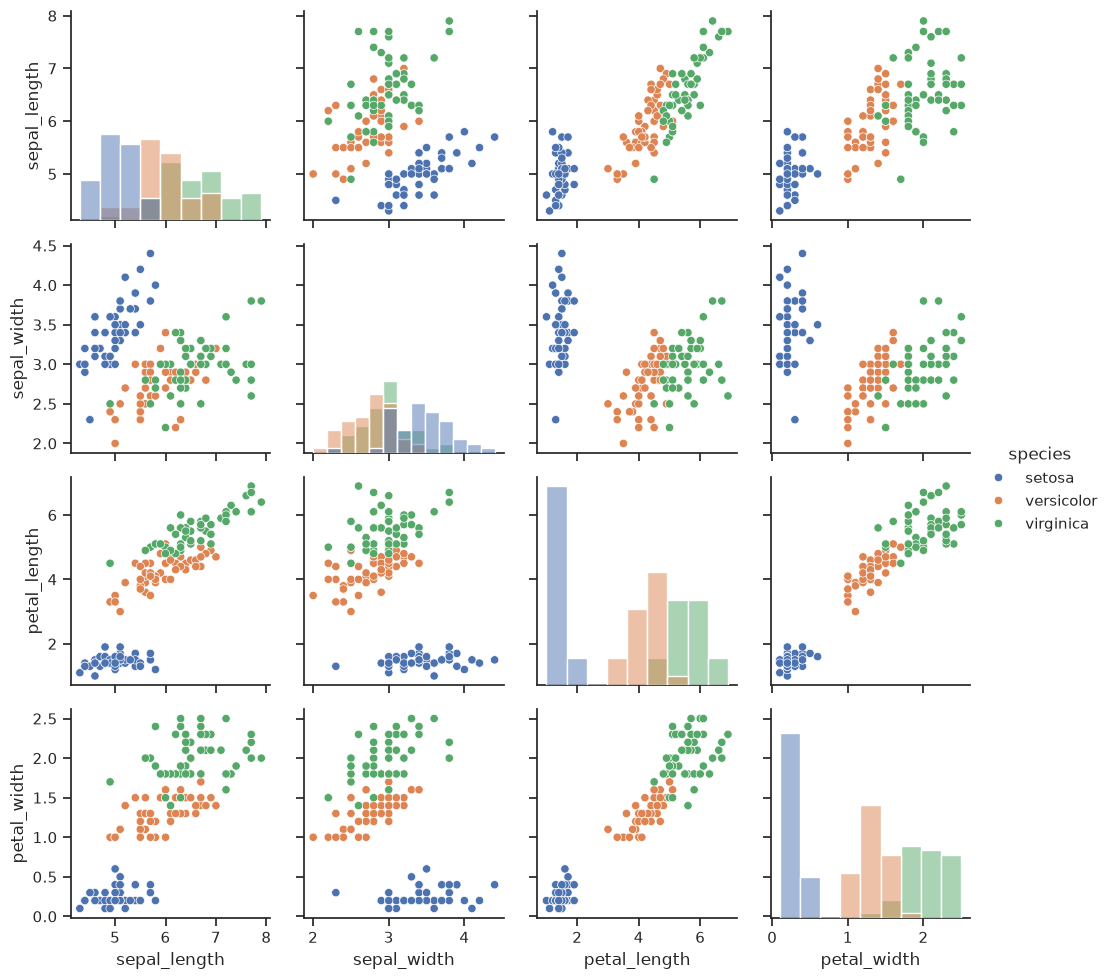

In [19]:
# Colour by a categorical variable
g = sns.PairGrid(iris, hue="species")
g.map_diag(sns.histplot)
g.map_offdiag(sns.scatterplot)
g.add_legend()

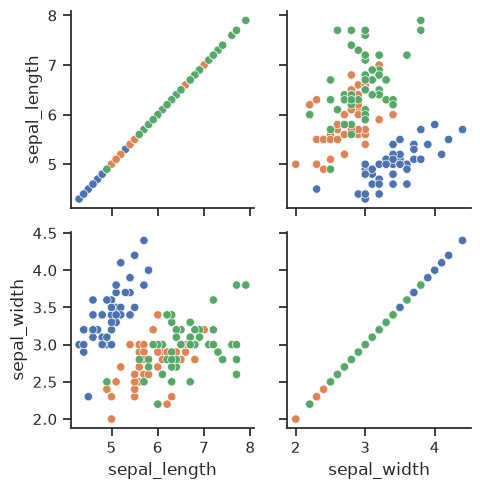

In [20]:
# Only some variables
g = sns.PairGrid(iris, vars=["sepal_length", "sepal_width"], hue="species")
g.map(sns.scatterplot)

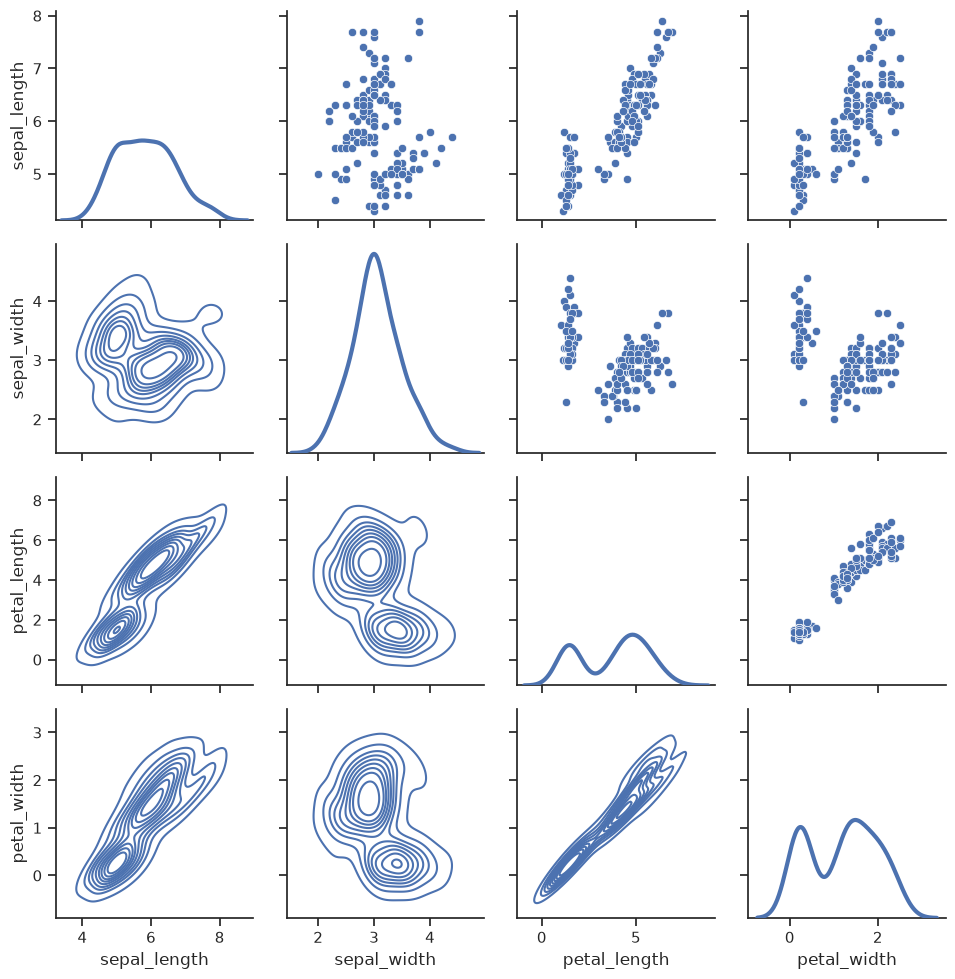

In [21]:
# Different functions for the upper triangle, lower triangle and diagonal
g = sns.PairGrid(iris)
g.map_upper(sns.scatterplot)
g.map_lower(sns.kdeplot)
g.map_diag(sns.kdeplot, lw=3, legend=False)

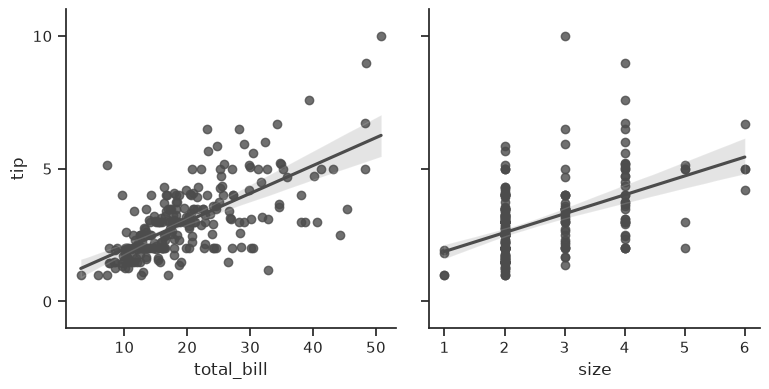

In [22]:
# Not necessarily square: different variables on rows and columns
g = sns.PairGrid(tips, y_vars=["tip"], x_vars=["total_bill", "size"], height=4)
g.map(sns.regplot, color=".3")
g.set(ylim=(-1, 11), yticks=[0, 5, 10])

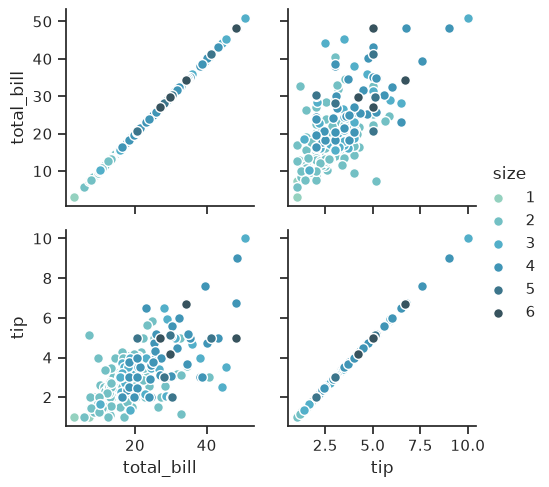

In [23]:
# Custom palette (ordered hue) and keyword arguments for the plot function
g = sns.PairGrid(tips, hue="size", palette="GnBu_d")
g.map(plt.scatter, s=50, edgecolor="white")
g.add_legend()

For a quick look, `pairplot` trades flexibility for speed (scatterplots + histograms by default; `kind="reg"`, `diag_kind="kde"` also available):

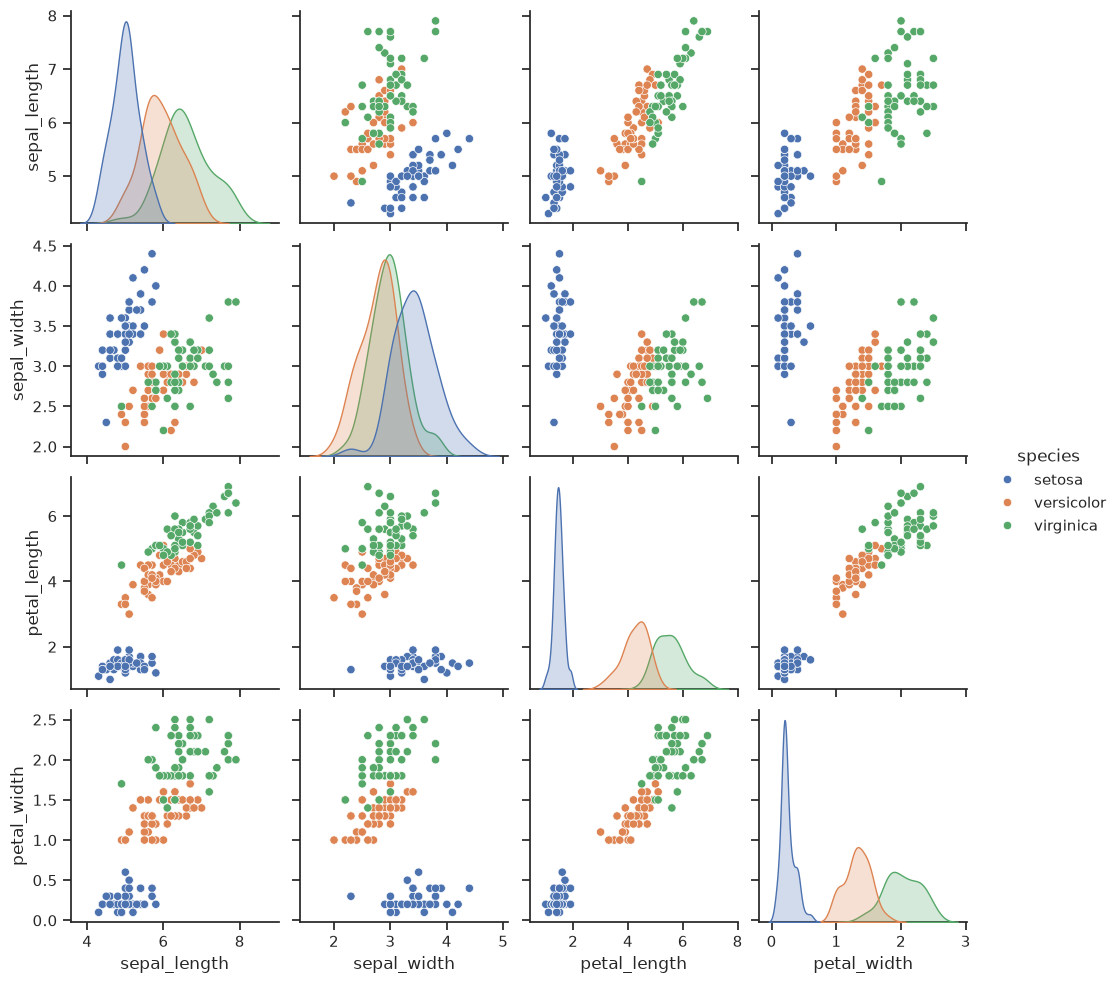

In [24]:
sns.pairplot(iris, hue="species", height=2.5)

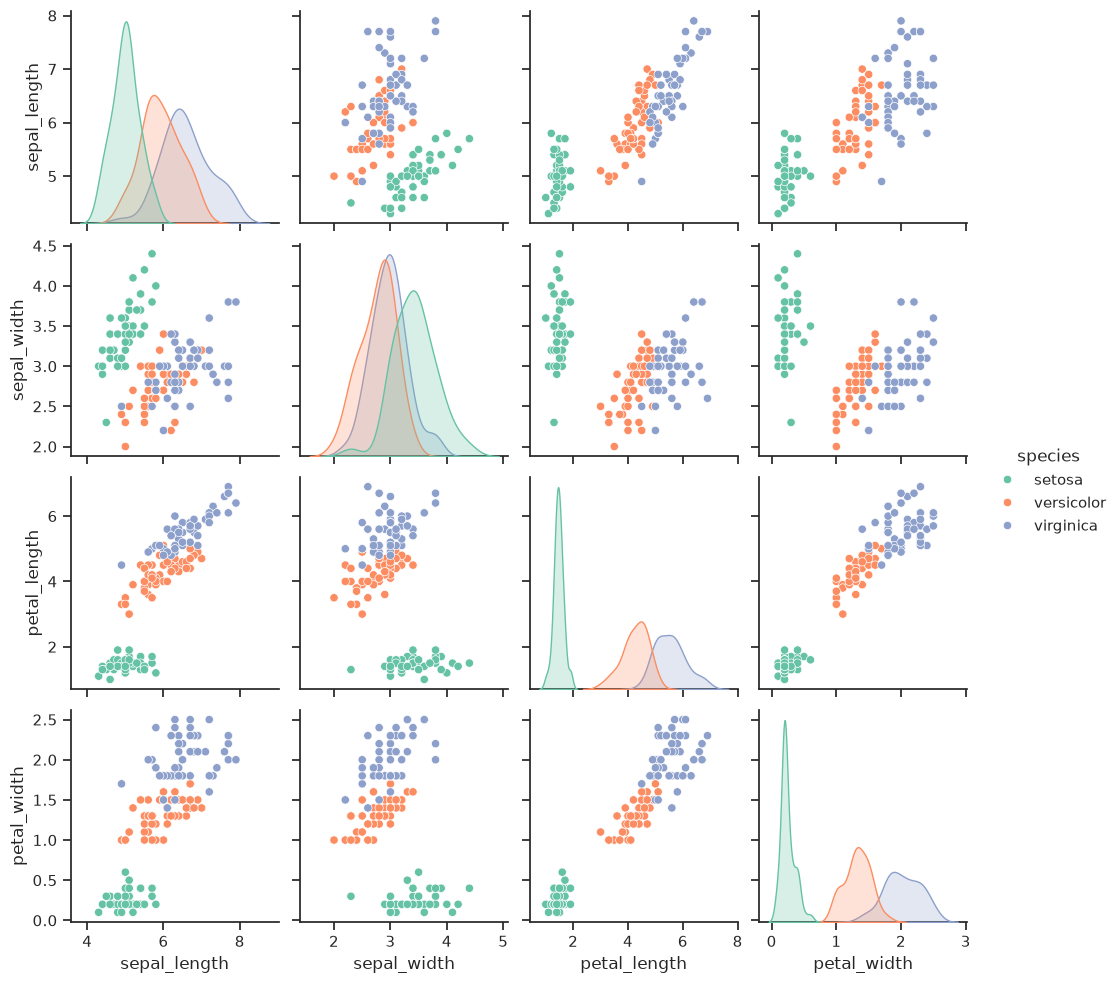

In [25]:
# Returns the PairGrid for further tweaking
g = sns.pairplot(iris, hue="species", palette="Set2", diag_kind="kde", height=2.5)

## Key takeaways

- `FacetGrid(data, row=, col=, hue=, col_wrap=, height=, aspect=)` → `.map(func, "x", "y")` or `.map_dataframe(func, x=, y=)` → `.add_legend()`, `.set(...)`, `.set_axis_labels(...)`, `.set_titles(...)`.
- Reach matplotlib via `g.figure`, `g.axes`, `g.axes_dict`, `g.ax`.
- Custom functions: draw on the current Axes, take data positionally, accept `color`/`label` (`**kwargs`).
- `PairGrid` / `pairplot`: every pair of variables; `map_upper` / `map_lower` / `map_diag`.